# **Dataset: Magic Gamma Telescope**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import time
from scipy.stats import uniform, randint
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.inspection import permutation_importance, DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, learning_curve, cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

## **Dataset Info**

In [30]:
column_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
]

df = pd.read_csv('magic04.data', header=None, names=column_names)
df['class'] = df['class'].map({'g': 1, 'h': 0})
df.to_csv('magic_gamma_telescope.csv', index=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.6 MB


The original dataset contains **19,020 samples** with **ten continuous features** (Hillas parameters):

- **`fLength`** (real): major axis of ellipse [mm] — longitudinal extension of the shower  
- **`fWidth`** (real): minor axis of ellipse [mm] — transverse extension of the shower  
- **`fSize`** (real): 10-log of sum of content of all pixels [#phot] — total energy deposited  
- **`fConc`** (real): ratio of sum of two highest pixels over fSize — light concentration  
- **`fConc1`** (real): ratio of highest pixel over fSize — maximum light concentration  
- **`fAsym`** (real): distance from highest pixel to center, projected onto major axis [mm] — asymmetry  
- **`fM3Long`** (real): 3rd root of third moment along major axis [mm] — longitudinal asymmetry  
- **`fM3Trans`** (real): 3rd root of third moment along minor axis [mm] — transverse asymmetry  
- **`fAlpha`** (real): angle of major axis with vector to origin [deg] — orientation angle  
- **`fDist`** (real): distance from origin to center of ellipse [mm] — shower position  
- **`class`** (binary, target): particle type (0 = hadron, 1 = gamma)

This dataset provides Cherenkov telescope measurements to **discriminate gamma rays from hadronic background**, using geometric and intensity parameters of electromagnetic showers.


## **Data Analysis**

Before modeling, it is important to **explore the dataset**, check class balance, understand feature distributions, and visualize relationships between features. This helps in selecting the right features and spotting potential issues.

### **Class Distribution**

The bar chart below shows the number of samples for each particle type:

- Skyblue bars represent gamma rays (1) — signal events  
- Orange bars represent hadrons (0) — background events  

The dataset is **imbalanced** with approximately 65% gamma and 35% hadron.

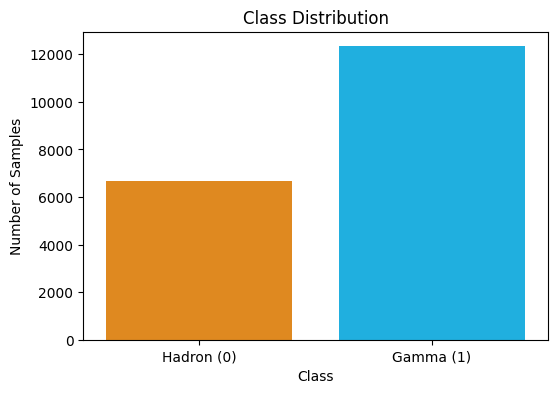

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x='class',
    hue='class',
    palette={0: 'darkorange', 1: 'deepskyblue'},
    dodge=False,
    legend=False
)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ['Hadron (0)', 'Gamma (1)'])
plt.show()

### **Histograms**

Histograms allow us to observe the **distribution of each Hillas parameter** and see how they differ between particle types:

- Skyblue distributions represent gamma rays (1) — signal  
- Orange distributions represent hadrons (0) — background  

Understanding these distributions helps identify which parameters are **more discriminative for gamma/hadron separation**.

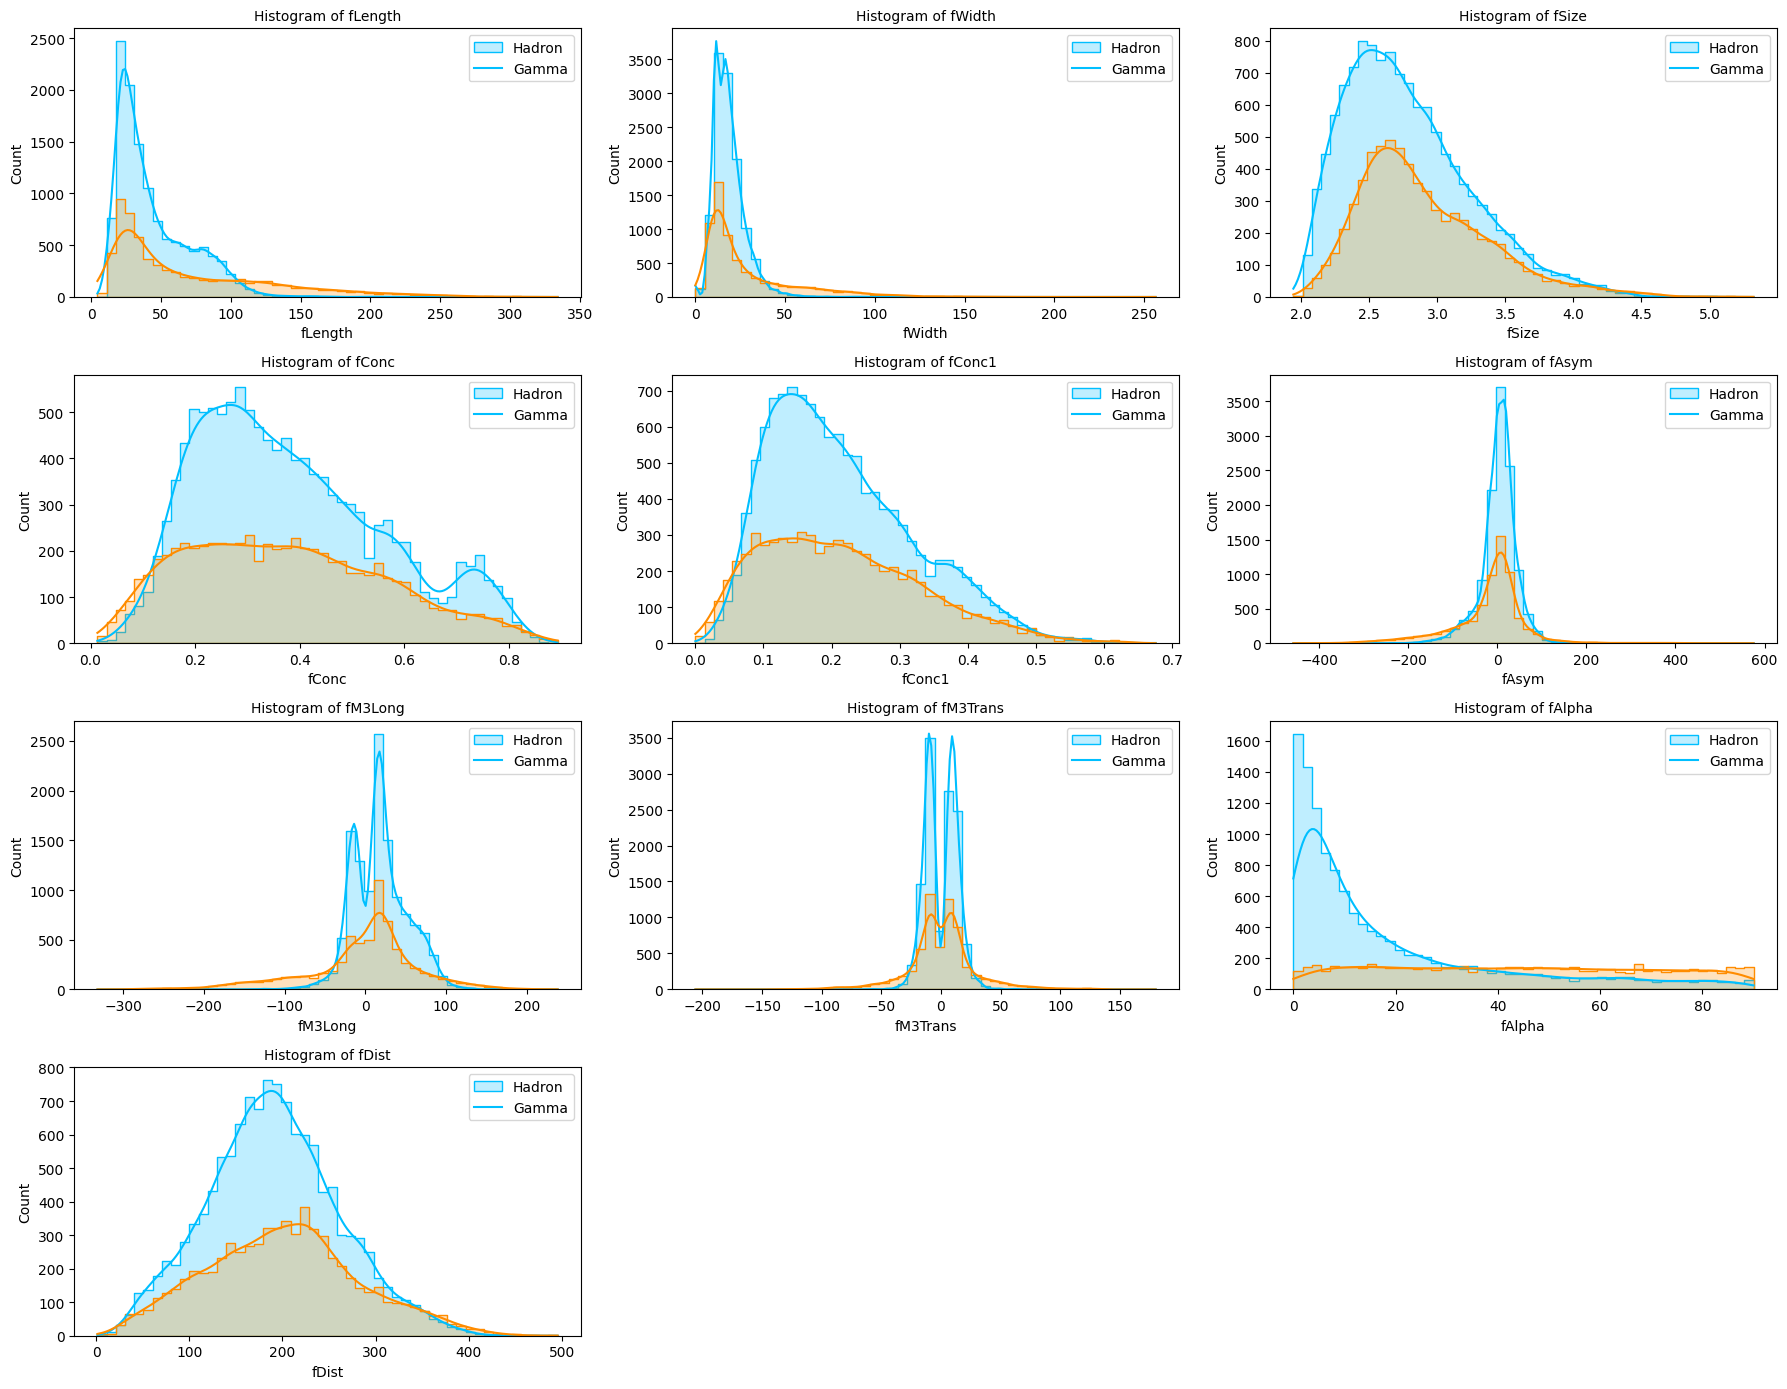

In [32]:
continuous_features = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
                       'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']

plt.figure(figsize=(18, 14))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(4, 3, i)
    sns.histplot(
        data=df,
        x=col,
        hue='class',
        kde=True,
        bins=50,
        element='step',
        palette={0: 'darkorange', 1: 'deepskyblue'}
    )
    plt.title(f"Histogram of {col}", fontsize=10)
    plt.legend(labels=['Hadron', 'Gamma'])

plt.tight_layout()
plt.show()


### **Correlation Heatmap**

The heatmap below visualizes pairwise correlations between Hillas parameters:

- Colors closer to **red** indicate strong positive correlation  
- Colors closer to **blue** indicate strong negative correlation  
- Colors closer to **white** indicate weak or no correlation  

This plot is useful to detect **redundant features** and understand the geometric relationships between shower parameters. For instance, `fConc` and `fConc1` are expected to be highly correlated as they both measure light concentration.

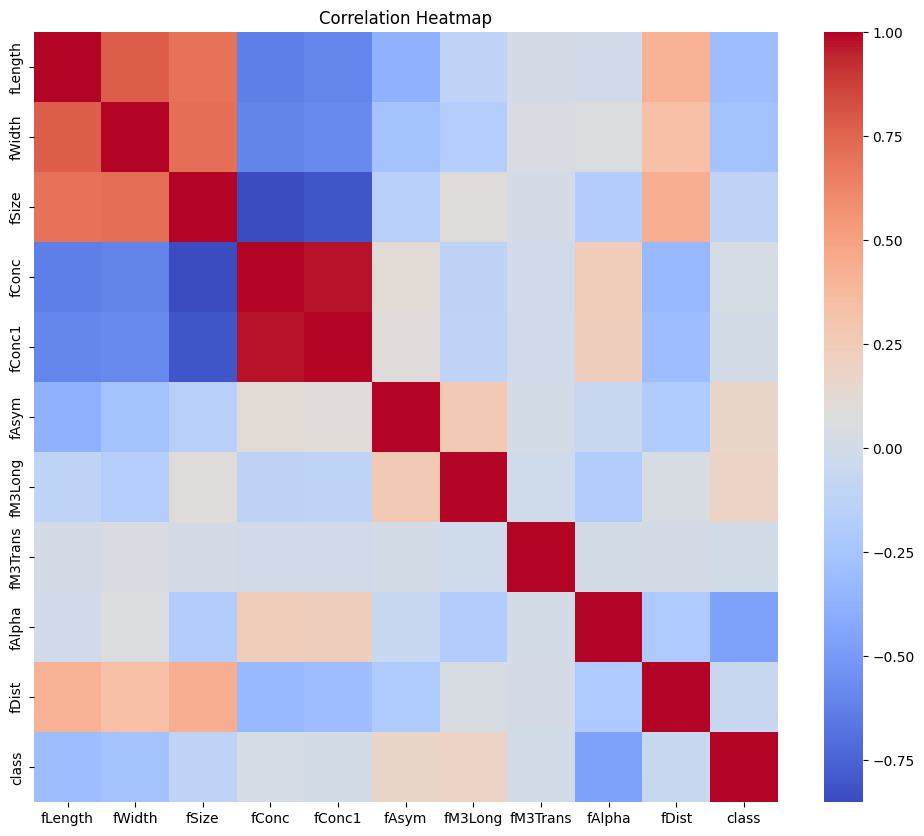

In [33]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

### **Pairplot of Selected Features**

The pairplot below visualizes the relationships between key Hillas parameters, colored by particle type:

- Diagonal plots display the distribution of each feature  
- Off-diagonal plots display relationships between feature pairs  
- Skyblue points represent gamma rays (signal)  
- Orange points represent hadrons (background)  

This visualization highlights patterns and separations between gamma and hadron showers, helping to **identify which parameters provide the best discrimination**. Clear separation in parameter space indicates good classification potential.

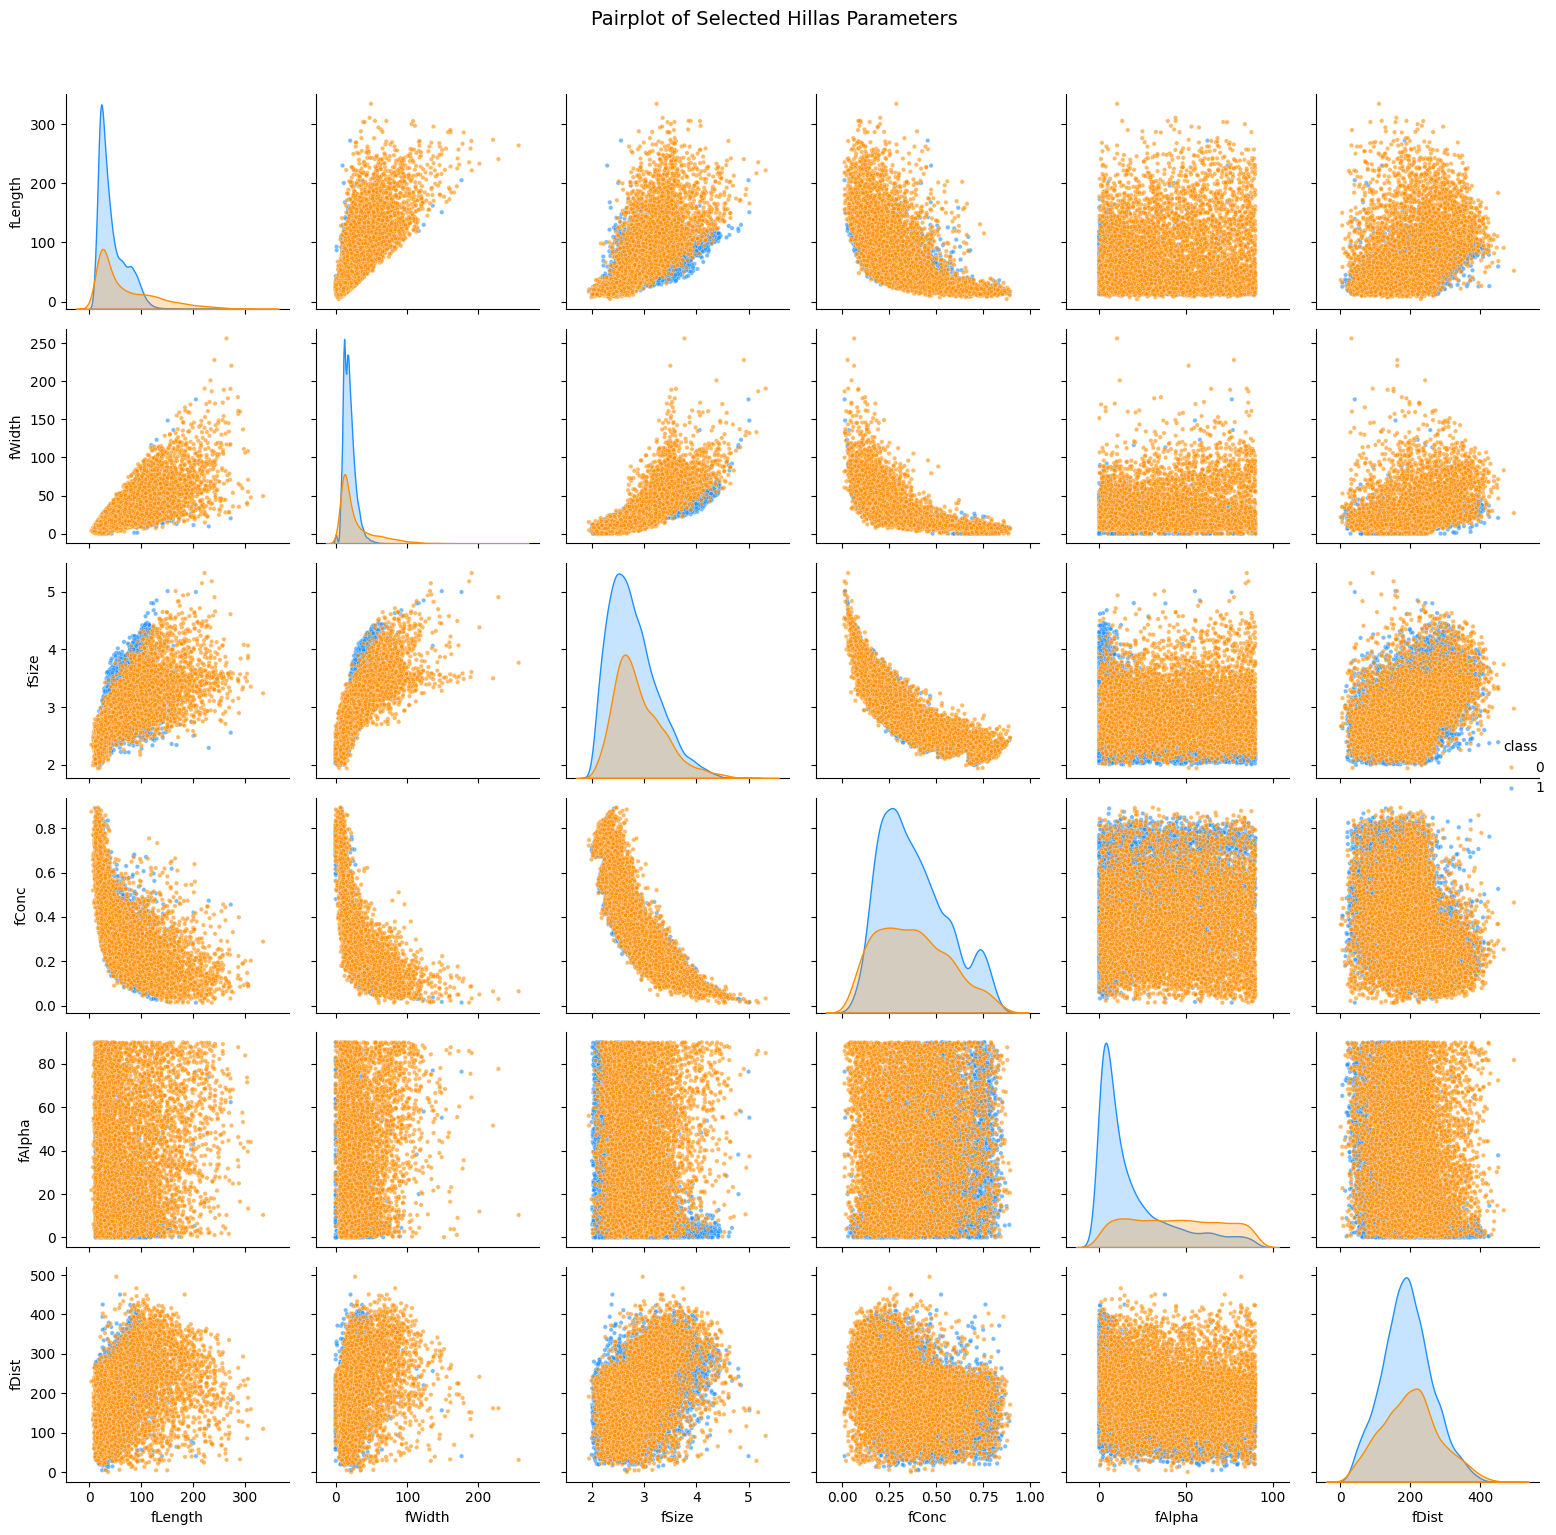

In [34]:
selected_features = ['fLength', 'fWidth', 'fSize', 'fConc', 'fAlpha', 'fDist']
sns.pairplot(
    df,
    vars=selected_features,
    hue='class',
    palette={0: 'darkorange', 1: 'dodgerblue'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 10}
)
plt.suptitle("Pairplot of Selected Hillas Parameters", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## **Data Pre-processing**

The preprocessing phase is essential for preparing raw data so that it is usable and optimised for machine learning models; the quality of the model depends heavily on the quality of the data. In fact, real datasets are *rarely perfect*.

### **Checking for Missing Values**

The first step is to check the dataset for any missing values. Identifying missing data is essential to ensure that the analysis and modeling are accurate and not affected by incomplete information. This step helps to decide whether imputation or removal of missing values is necessary before further processing.

In [35]:
missing_values = df.isnull().sum()
print(missing_values)

fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64


### **Preparing Features and Target**

The dataset is split into **input features (`X`)** and the **target variable (`y`)**, where `y` contains the particle class (0 = hadron, 1 = gamma). This setup clearly separates the predictors from the outcome, allowing the model to learn patterns that distinguish signal from background.

- `feature_names` stores the names of the 10 Hillas parameters for use in later visualizations and analysis  
- `class_names` stores the two particle types (`['Hadron', 'Gamma']`) for use in later visualizations and analysis

In [36]:
X = df.drop(columns=['class'])
y = df['class']

feature_names = X.columns.tolist()
class_names = ['Hadron', 'Gamma']

### **Dataset Splitting**

The dataset is split into **training and test sets** to properly evaluate model performance:

- **Training set** (75%): used to fit the models and perform cross-validation for hyperparameter tuning  
- **Test set** (25%): used to evaluate the final performance on unseen data  

Shuffling is applied to ensure random sampling, while **stratification** preserves the original proportion of gamma and hadron samples (approximately 65% gamma, 35% hadron). This is important to maintain the class balance in both sets.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42, stratify=y
)

### **Feature Preprocessing**

All ten features are **continuous Hillas parameters** representing geometric and intensity properties of Cherenkov showers. They are scaled using **standardization (Z-score scaling)** to ensure that they have a mean of 0 and a standard deviation of 1. Scaling is essential because:

- Features have different units and scales (e.g., `fLength` in mm, `fConc` as ratio, `fAlpha` in degrees)  
- Many machine learning algorithms (SVM, Logistic Regression) are sensitive to feature scales  

The `StandardScaler` is **fitted only on the training set** to avoid information leakage, then the same transformation is applied to the test set using `transform`.

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## **Model Implementation and Training**

### **Storage Structures**

Before training models, we define **empty lists** to store important information:

- `performances`: will hold metrics (accuracy, precision, recall, F1) for each model  
- `training_times_list`: will store the training time of each model  
- `model_results`: will keep the trained models and their predictions  
- `classification_reports`: will save the detailed classification reports  

In [39]:
performances = []
training_times_list = []
model_results = []
classification_reports = []

### Training, Validation, and Model Evaluation Functions

These functions are designed to **train models, evaluate performance, and visualize results** for gamma/hadron discrimination:

1. **Cross-validation comparison**  
   `evaluate_model_with_cv` runs 5-fold stratified cross-validation, computing accuracy, precision, recall, F1-score, and **ROC-AUC** for both training and validation sets. Results are plotted as side-by-side bar charts for easy comparison.

2. **Batch plotting for all models**  
   `training_vs_validation` creates a 3×2 grid of all model training-vs-validation plots, making it simple to see performance differences across all classifiers simultaneously.

3. **Detailed classification reports**  
   `print_classification_reports` prints structured reports for each model, showing precision, recall, and F1-score for both gamma (signal) and hadron (background) classes.

4. **Validation metrics summary**  
   `validation_metrics` plots horizontal bar charts to compare accuracy, precision, recall, F1-score, and **ROC-AUC** across all models. The aim of this function is to help identify the best performing models for gamma/hadron discrimination.

5. **Training time comparison**  
   `training_times_comparison` visualizes the computational cost of training each model on a logarithmic scale, highlighting efficiency trade-offs.

6. **Confusion matrices**  
   `confusion_matrix_on_ax` shows correct and incorrect predictions for each model. It compares predicted particle types with true labels, revealing how many gamma rays and hadrons are correctly or incorrectly classified. This is crucial for understanding the balance between signal acceptance and background rejection.

7. **ROC curves and AUC**  
   `roc_curve_on_ax` plots the Receiver Operating Characteristic (ROC) curve and computes the Area Under the Curve (AUC). The ROC curve illustrates the trade-off between True Positive Rate (gamma acceptance) and False Positive Rate (hadron contamination). **AUC is the primary evaluation metric** for this dataset, as it measures discrimination ability independent of classification threshold. A higher AUC indicates better separation between gamma signal and hadronic background.

8. **Learning curves**  
   `learning_curve_on_ax` shows how model performance changes as the training set size increases. Both training and validation scores are plotted with **confidence bands** (mean ± standard deviation) to detect overfitting, underfitting, or convergence trends. This helps determine whether collecting more data could improve discrimination performance.

9. **Feature importance**  
   `feature_importances_on_ax` evaluates which Hillas parameters are most influential for gamma/hadron separation. Tree-based models use built-in feature importance; other models use permutation importance. This reveals which geometric and intensity features contribute most to classification decisions.

10. **Decision boundaries**  
    `decision_boundaries_on_ax` reduces the 10-dimensional Hillas parameter space to two principal components using PCA and visualizes the model's decision boundaries. Training samples (circles) and test samples (triangles) are plotted for both gamma (skyblue) and hadron (orange) classes, showing how well the model separates particle types in reduced 2D space.

11. **Batch plotting utilities**  
    Functions like `confusion_matrices`, `roc_curves`, `learning_curves`, `feature_importances`, and `decision_boundaries` generate plots for all six models in a 3×2 layout for comprehensive side-by-side comparison.

12. **Automated training and evaluation**  
    `train_and_evaluate_model` combines hyperparameter search (GridSearchCV or RandomizedSearchCV with **`scoring='roc_auc'`**), model fitting, prediction, and result storage in one step. It prints training duration and the best hyperparameters found, then stores predictions and probability scores for downstream analysis.

In [40]:
def evaluate_model_with_cv(estimator, model_name, X_train, y_train, performances, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1)

    train_metrics = {m: np.mean(scores[f'train_{m}']) for m in scoring}
    val_metrics = {m: np.mean(scores[f'test_{m}']) for m in scoring}

    performances.append({
        'model': model_name,
        'metrics': {
            'Accuracy': val_metrics['accuracy'],
            'Precision': val_metrics['precision'],
            'Recall': val_metrics['recall'],
            'F1-score': val_metrics['f1'],
            'ROC-AUC': val_metrics['roc_auc']
        }
    })

    scoring_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
    train_values = [train_metrics[m] for m in scoring]
    val_values = [val_metrics[m] for m in scoring]

    train_color = "#FFB366"
    val_color   = "#87CEEB"

    x = np.arange(len(scoring_labels))
    width = 0.35

    ax.bar(x - width/2, train_values, width=width, color=train_color, label='Train')
    ax.bar(x + width/2, val_values, width=width, color=val_color, label='Validation')

    ax.set_title(model_name, fontsize=11)
    ax.set_xticks(range(len(scoring_labels)))
    ax.set_xticklabels(scoring_labels, fontsize=9, rotation=15)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1)
    ax.legend(loc='best', fontsize=9)

    return ax


def training_vs_validation(model_results, X_train, y_train, performances):
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()

    for i, result in enumerate(model_results):
        evaluate_model_with_cv(result['estimator'], result['model_name'], X_train, y_train, performances, ax=axes[i])

    plt.suptitle('Training vs Validation', fontsize=16)
    plt.tight_layout()
    plt.show()


def print_classification_reports(classification_reports):
    print("\nClassification Reports\n")

    for i in classification_reports:
        print(f"Model: {i['model_name']}")
        print("-" * 60)
        print(i['report'])
        print()


def validation_metrics(performances):
    models = [p['model'] for p in performances]

    scoring = {
        'Accuracy': [p['metrics']['Accuracy'] for p in performances],
        'Precision': [p['metrics']['Precision'] for p in performances],
        'Recall': [p['metrics']['Recall'] for p in performances],
        'F1-score': [p['metrics']['F1-score'] for p in performances],
        'ROC-AUC': [p['metrics']['ROC-AUC'] for p in performances]
    }

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, (scoring_name, values) in enumerate(scoring.items()):
        bars = axes[i].barh(models, values, color="#87CEEB", alpha=0.85)
        
        axes[i].set_title(f'{scoring_name}', fontsize=12)
        axes[i].set_xlim(0, 1)
        axes[i].grid(axis='x', linestyle='--', alpha=0.3)
        axes[i].bar_label(bars, fmt="%.3f", padding=3)

    axes[-1].axis('off')

    plt.suptitle("Validation Metrics Across Models", fontsize=16)
    plt.tight_layout()
    plt.show()


def training_times_comparison(training_times_list):
    models = [t['model_name'] for t in training_times_list]
    times = [t['t'] for t in training_times_list]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(models, times, color="#FFB366")
    plt.bar_label(bars, labels=[f"{t:.2f}s" for t in times], padding=3)

    plt.xlabel("Training time (s)", fontsize=11)
    plt.title("Training Time Comparison", fontsize=14)
    plt.xscale('log')
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()


def confusion_matrix_on_ax(y_true, y_pred, model_name, class_names, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    cm = confusion_matrix(y_true, y_pred)

    colors = ['#E8F4F8', '#87CEEB', '#FFB366']
    cmap = LinearSegmentedColormap.from_list('sky_orange', colors, N=100)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names, ax=ax)

    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

    return ax


def roc_curve_on_ax(y_true, y_scores, model_name, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)

    ax.plot(fpr, tpr, color="#FF9966", linewidth=2, label=f'{model_name}')
    ax.fill_between(fpr, tpr, alpha=0.2, color='#FFB366', label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], color='#87CEEB', linestyle='--', label='Random predictor')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_title(model_name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)

    return auc


def learning_curve_on_ax(estimator, X_train, y_train, scoring, model_name, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(estimator=estimator, X=X_train, y=y_train, cv=cv, scoring=scoring, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="#FFB366", label="Training", linewidth=2)
    ax.plot(train_sizes, val_mean, 'o-', color="#87CEEB", label="Validation", linewidth=2)

    ax.set_title(model_name)
    ax.set_xlabel('Training Size')
    ax.set_ylabel(f'{scoring} score')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=8)

    return ax


def feature_importances_on_ax(estimator, X_test, y_test, feature_names, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    if hasattr(estimator, "feature_importances_"):
        importances = estimator.feature_importances_
    else:
        perm = permutation_importance(estimator=estimator, X=X_test, y=y_test, scoring="f1", n_jobs=-1, random_state=42)
        importances = perm.importances_mean

    indices = np.argsort(importances)[::-1]

    ax.bar(np.arange(len(feature_names)), importances[indices], width=0.6, color="#7EB6D4")
    ax.set_xticks(np.arange(len(feature_names)))
    ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, fontsize=9, ha='right')
    ax.set_ylabel("Importance", fontsize=10)
    ax.set_title(model_name, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    return ax


def decision_boundaries_on_ax(estimator, X_train, y_train, X_test, y_test, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    estimator.fit(X_train_pca, y_train)

    colors_boundary = ['#87CEEB', '#FFDAB3', '#FFB366']
    cmap_boundary = LinearSegmentedColormap.from_list('sky_peach', colors_boundary)

    DecisionBoundaryDisplay.from_estimator(estimator, X_train_pca, response_method="predict", cmap=cmap_boundary, alpha=0.35, ax=ax)

    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=cmap_boundary, s=25, edgecolor="black", alpha=0.6, label="Train")
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=cmap_boundary, s=45, marker="^", edgecolor="black", alpha=0.85, label="Test")

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(model_name, fontsize=12)
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFB366', 
               markersize=8, label='Train - Hadron'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#87CEEB', 
               markersize=8, label='Train - Gamma'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#FFB366', 
               markersize=8, label='Test - Hadron'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#87CEEB', 
               markersize=8, label='Test - Gamma')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=7)

    return ax


def confusion_matrices(model_results, class_names):
    fig, axes = plt.subplots(3, 2, figsize=(10, 15))
    axes = axes.flatten()

    for i, res in enumerate(model_results): 
        confusion_matrix_on_ax(res["y_test"], res["y_test_pred"], res["model_name"], class_names, ax=axes[i])

    plt.suptitle("Confusion Matrices", fontsize=16)
    plt.tight_layout()
    plt.show()


def roc_curves(model_results):
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()

    for i, res in enumerate(model_results):
        roc_curve_on_ax(res["y_test"], res["y_test_proba"], res["model_name"], ax=axes[i])

    plt.suptitle("ROC Curves and AUC", fontsize=16)
    plt.tight_layout()
    plt.show()


def learning_curves(model_results, X_train, y_train):
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()

    for i, res in enumerate(model_results):
        learning_curve_on_ax(res["estimator"], X_train, y_train, "roc_auc", res["model_name"], ax=axes[i])

    plt.suptitle("Learning Curves", fontsize=16)
    plt.tight_layout()
    plt.show()


def feature_importances(model_results, X_test, y_test, feature_names):
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()

    for i, res in enumerate(model_results):
        feature_importances_on_ax(res["estimator"], X_test, y_test, feature_names, res["model_name"], ax=axes[i])

    plt.suptitle("Feature Importances", fontsize=16)
    plt.tight_layout()
    plt.show()


def decision_boundaries(model_results, X_train, y_train, X_test, y_test):
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    axes = axes.flatten()

    for i, res in enumerate(model_results):
        decision_boundaries_on_ax(res["estimator"], X_train, y_train, X_test, y_test, res["model_name"], ax=axes[i])

    plt.suptitle("Decision Boundaries", fontsize=16)
    plt.tight_layout()
    plt.show()


def train_and_evaluate_model(model, param_grid, model_name, search_type="grid", n_iter=20, X_train=None, y_train=None, X_test=None, y_test=None, cv=None):
    if search_type == "grid":
        search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            return_train_score=True
        )
    else:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            random_state=42,
            return_train_score=True
        )

    start = time.time()
    search.fit(X_train, y_train)
    end = time.time()

    best_estimator = search.best_estimator_
    y_pred = best_estimator.predict(X_test)
    y_proba = best_estimator.predict_proba(X_test)[:, 1]

    model_results.append({
        "model_name": model_name,
        "estimator": best_estimator,
        "y_test": y_test,
        "y_test_pred": y_pred,
        "y_test_proba": y_proba
    })

    training_times_list.append({
        "model_name": model_name,
        "t": round(end - start, 2)
    })

    report = classification_report(y_test, y_pred, target_names=class_names)

    classification_reports.append({
        "model_name": model_name,
        "report": report
    })

    print(f"\nTraining {model_name} completed in {end - start:.2f} s.")
    print(f"\nBest hyper-parameters: {search.best_params_}")

    return best_estimator

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_SVM = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

### **Naïve Bayes**

The Naïve Bayes classifier assumes that all features are independent. It predicts probabilities for each class using `predict_proba`. **Hyperparameter tuning** is performed on `var_smoothing` using 5-fold stratified cross-validation, optimizing the **F1-score**.

In [42]:
model = GaussianNB()
param_grid = {'var_smoothing': np.logspace(-10, -3, 20)}
model_name = 'Naive Bayes'
search_type = 'grid'
train_and_evaluate_model(model, param_grid, model_name, search_type, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv)


Training Naive Bayes completed in 4.77 s.

Best hyper-parameters: {'var_smoothing': np.float64(0.001)}


,priors,None
,var_smoothing,np.float64(0.001)


### **Logistic Regression**

Logistic Regression models the probability of a binary outcome using a linear combination of input features. Randomized search is applied to tune `C`, `penalty`, `solver`, `class_weight`, and `max_iter` with 5-fold stratified CV, optimizing **F1-score**.

In [43]:
model = LogisticRegression(random_state=42)
param_distributions = {
    'C': uniform(1, 20),
    'penalty': ['l1', 'l2'],
    'solver': ['saga'],
    'class_weight': ['balanced'], 
    'max_iter': [3000]
}
model_name = 'Logistic Regression'
search_type = 'random'
train_and_evaluate_model(model, param_distributions, model_name, search_type, n_iter=20, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv)


Training Logistic Regression completed in 1.16 s.

Best hyper-parameters: {'C': np.float64(1.0155753168202866), 'class_weight': 'balanced', 'max_iter': 3000, 'penalty': 'l2', 'solver': 'saga'}


,penalty,'l2'
,dual,False
,tol,0.0001
,C,np.float64(1.0155753168202866)
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,3000
,multi_class,'deprecated'


### **Decision Tree**

Decision Tree splits data based on feature values to predict the target. Randomized search tuned `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, and `class_weight` using 5-fold stratified CV with **F1-score** as the metric. 

In [44]:
model = DecisionTreeClassifier(random_state=42)
param_distributions = {
    'max_depth': randint(6, 12),
    'min_samples_split': randint(8, 20),
    'min_samples_leaf': randint(8, 16),
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}
model_name = 'Decision Tree'
search_type = 'random'
train_and_evaluate_model(model, param_distributions, model_name, search_type, n_iter=30, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv)


Training Decision Tree completed in 3.94 s.

Best hyper-parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 13, 'min_samples_split': 13}


,criterion,'entropy'
,splitter,'best'
,max_depth,9
,min_samples_split,13
,min_samples_leaf,13
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


### **Random Forest**

Random Forest aggregates multiple decision trees to improve prediction accuracy and reduce overfitting. Hyperparameters `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`, and `class_weight` were tuned using 5-fold stratified CV with **F1-score** optimization.

In [45]:
model = RandomForestClassifier(random_state=42)
param_distributions = {
    'n_estimators': randint(100, 200),
    'max_depth': randint(10, 18),
    'min_samples_split': randint(10, 30),
    'min_samples_leaf': randint(5, 15),
    'max_features': ['sqrt', 0.7, 0.8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
} 
model_name = 'Random Forest'
search_type = 'random'
train_and_evaluate_model(model, param_distributions, model_name, search_type, n_iter=30, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv)


Training Random Forest completed in 216.11 s.

Best hyper-parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 14, 'n_estimators': 150}


,n_estimators,150
,criterion,'entropy'
,max_depth,17
,min_samples_split,14
,min_samples_leaf,7
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### **SVM Linear**

Support Vector Machine with linear kernel separates classes using a linear decision boundary. Randomized search tuned `C` and `class_weight` with 5-fold stratified CV, optimizing **F1-score**. The model predicts probabilities using `predict_proba`.

In [46]:
model = SVC(kernel='linear', probability=True, random_state=42)
param_distributions = {
    'C': uniform(1, 20),
    'class_weight': ['balanced']
}
model_name = 'SVM Linear'
search_type = 'random'
train_and_evaluate_model(model, param_distributions, model_name, search_type, n_iter=10, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv_SVM)


Training SVM Linear completed in 198.51 s.

Best hyper-parameters: {'C': np.float64(18.323522915498703), 'class_weight': 'balanced'}


,C,np.float64(18.323522915498703)
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


### **SVM Kernel-based**

Kernel-based SVM (RBF kernel) maps input features into a higher-dimensional space for non-linear separation. Hyperparameters `C`, `gamma`, and `class_weight` were tuned with 5-fold stratified CV to maximize **F1-score**.

In [47]:
model = SVC(kernel='rbf', probability=True, random_state=42)
param_distributions = {
    'C': uniform(5, 15),
    'gamma': ['scale', 'auto', 0.01, 0.05, 0.1],
    'class_weight': ['balanced']
}
model_name = 'SVM Kernel-based'
search_type = 'random'
train_and_evaluate_model(model, param_distributions, model_name, search_type, n_iter=10, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=cv_SVM)


Training SVM Kernel-based completed in 71.17 s.

Best hyper-parameters: {'C': np.float64(15.829981584002372), 'class_weight': 'balanced', 'gamma': 'auto'}


,C,np.float64(15.829981584002372)
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


## **Evaluation**

### **Classification Report**

In [48]:
print_classification_reports(classification_reports)


Classification Reports

Model: Naive Bayes
------------------------------------------------------------
              precision    recall  f1-score   support

      Hadron       0.72      0.38      0.50      1672
       Gamma       0.73      0.92      0.82      3083

    accuracy                           0.73      4755
   macro avg       0.73      0.65      0.66      4755
weighted avg       0.73      0.73      0.71      4755


Model: Logistic Regression
------------------------------------------------------------
              precision    recall  f1-score   support

      Hadron       0.68      0.72      0.70      1672
       Gamma       0.84      0.81      0.83      3083

    accuracy                           0.78      4755
   macro avg       0.76      0.76      0.76      4755
weighted avg       0.78      0.78      0.78      4755


Model: Decision Tree
------------------------------------------------------------
              precision    recall  f1-score   support

      Hadron  

### **Confusion Matrices**

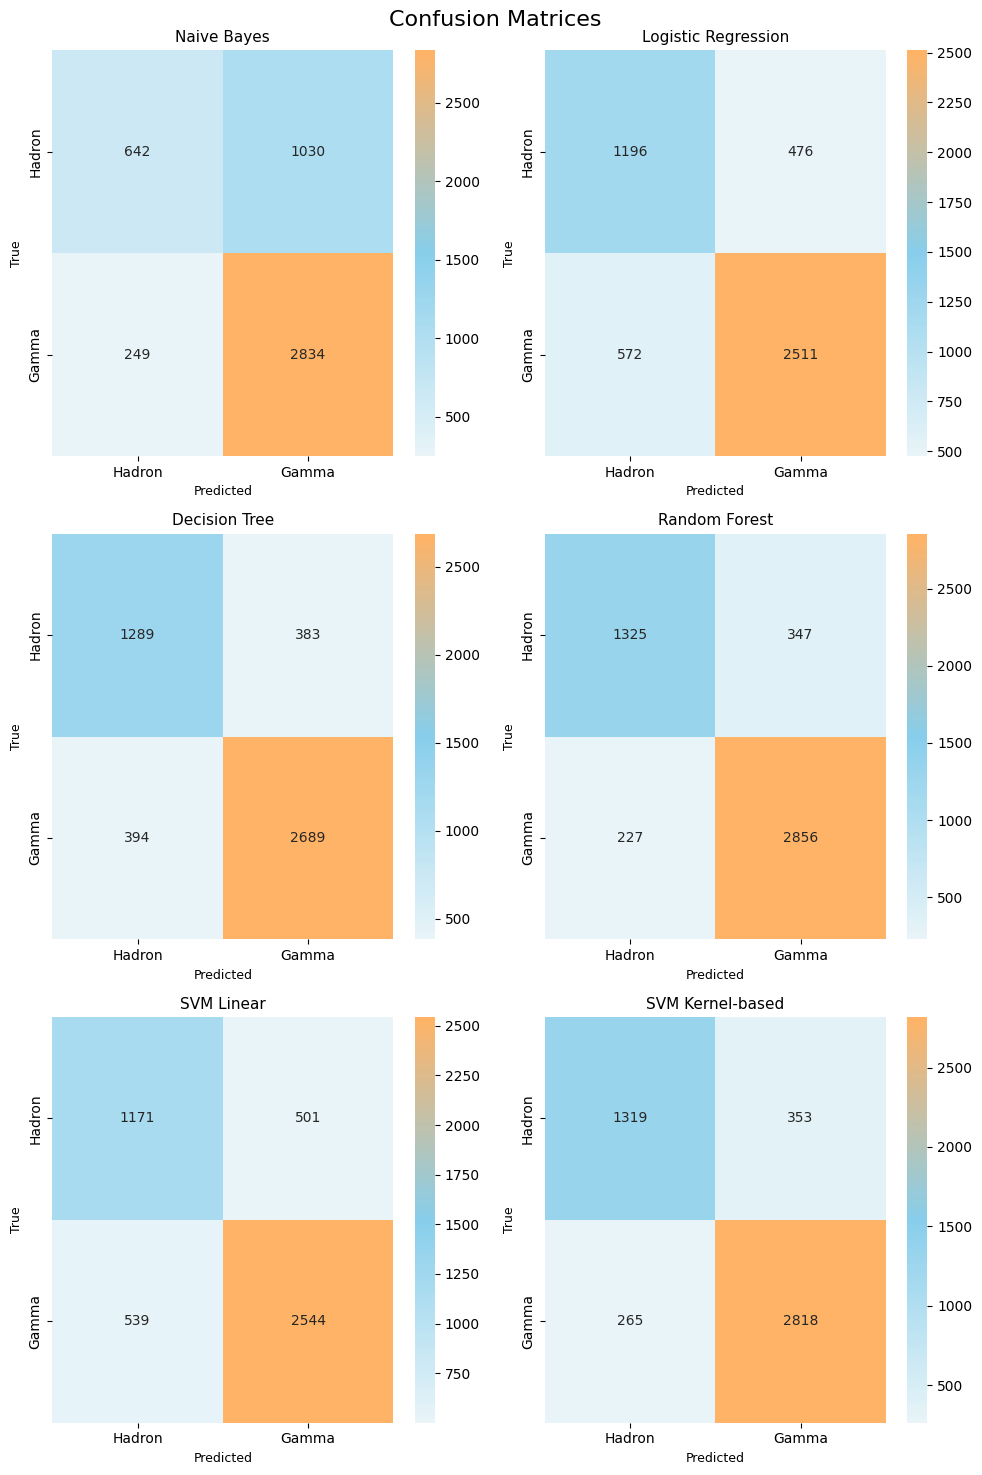

In [49]:
confusion_matrices(model_results, class_names)

### **ROC Curves and AUC**

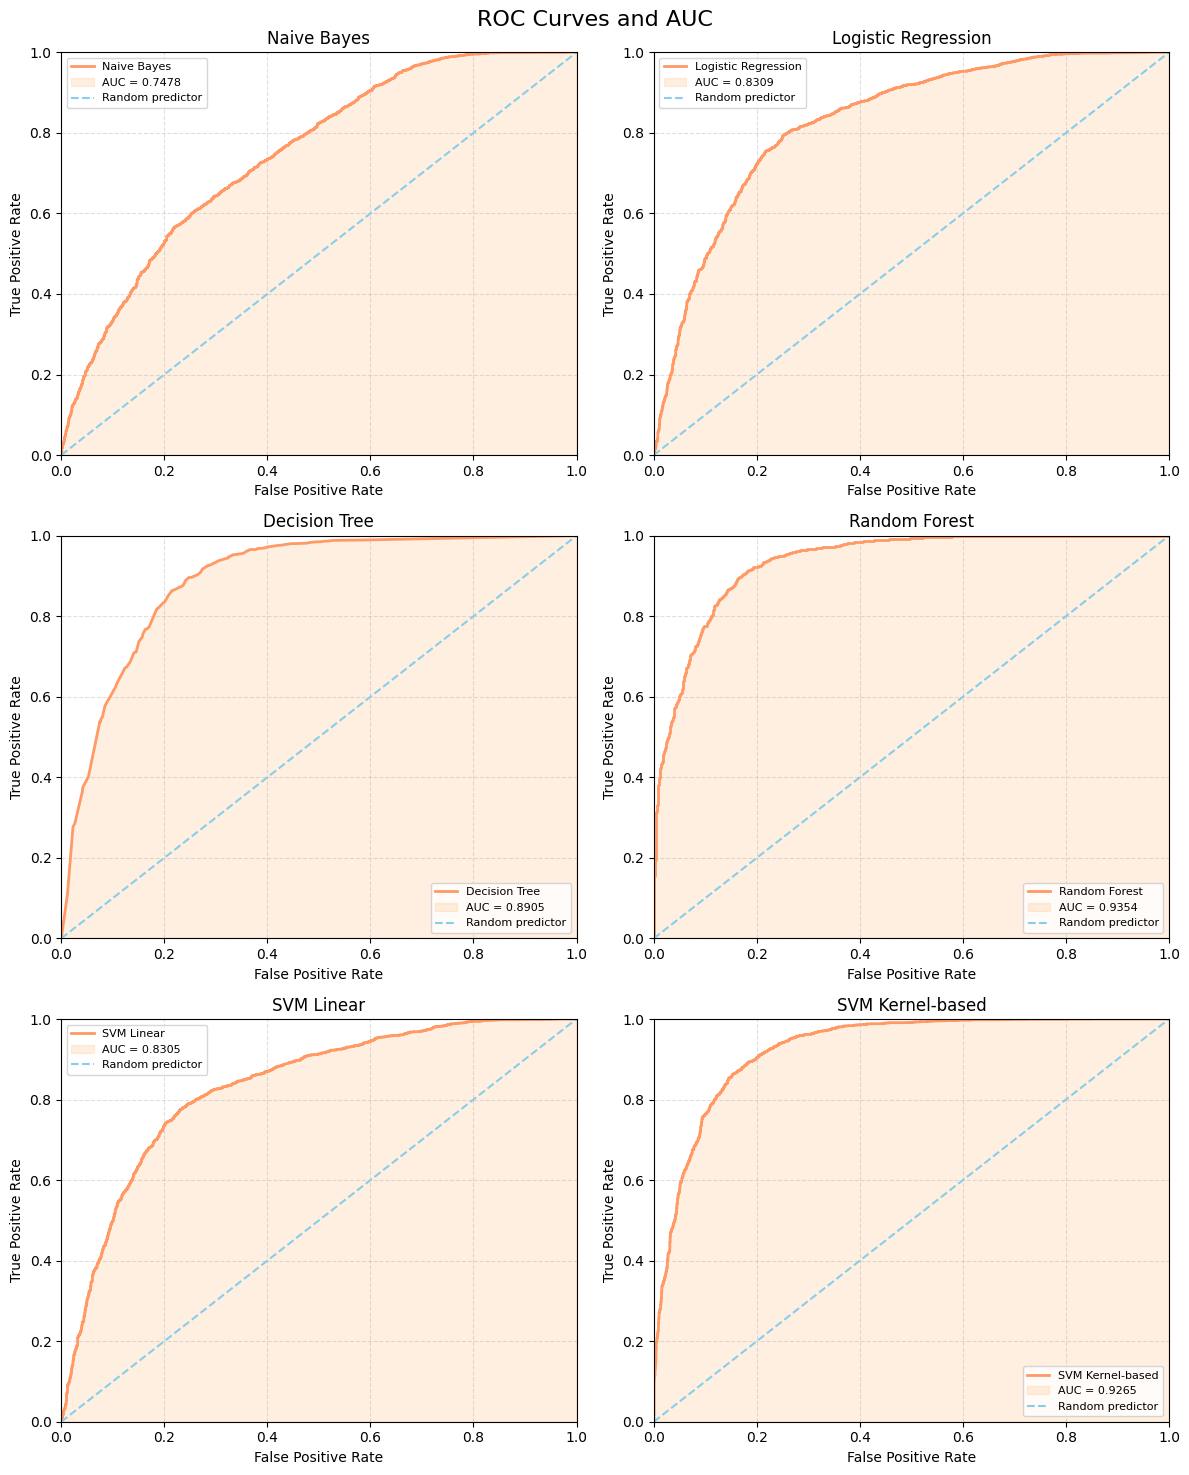

In [50]:
roc_curves(model_results)

### **Learning Curves**

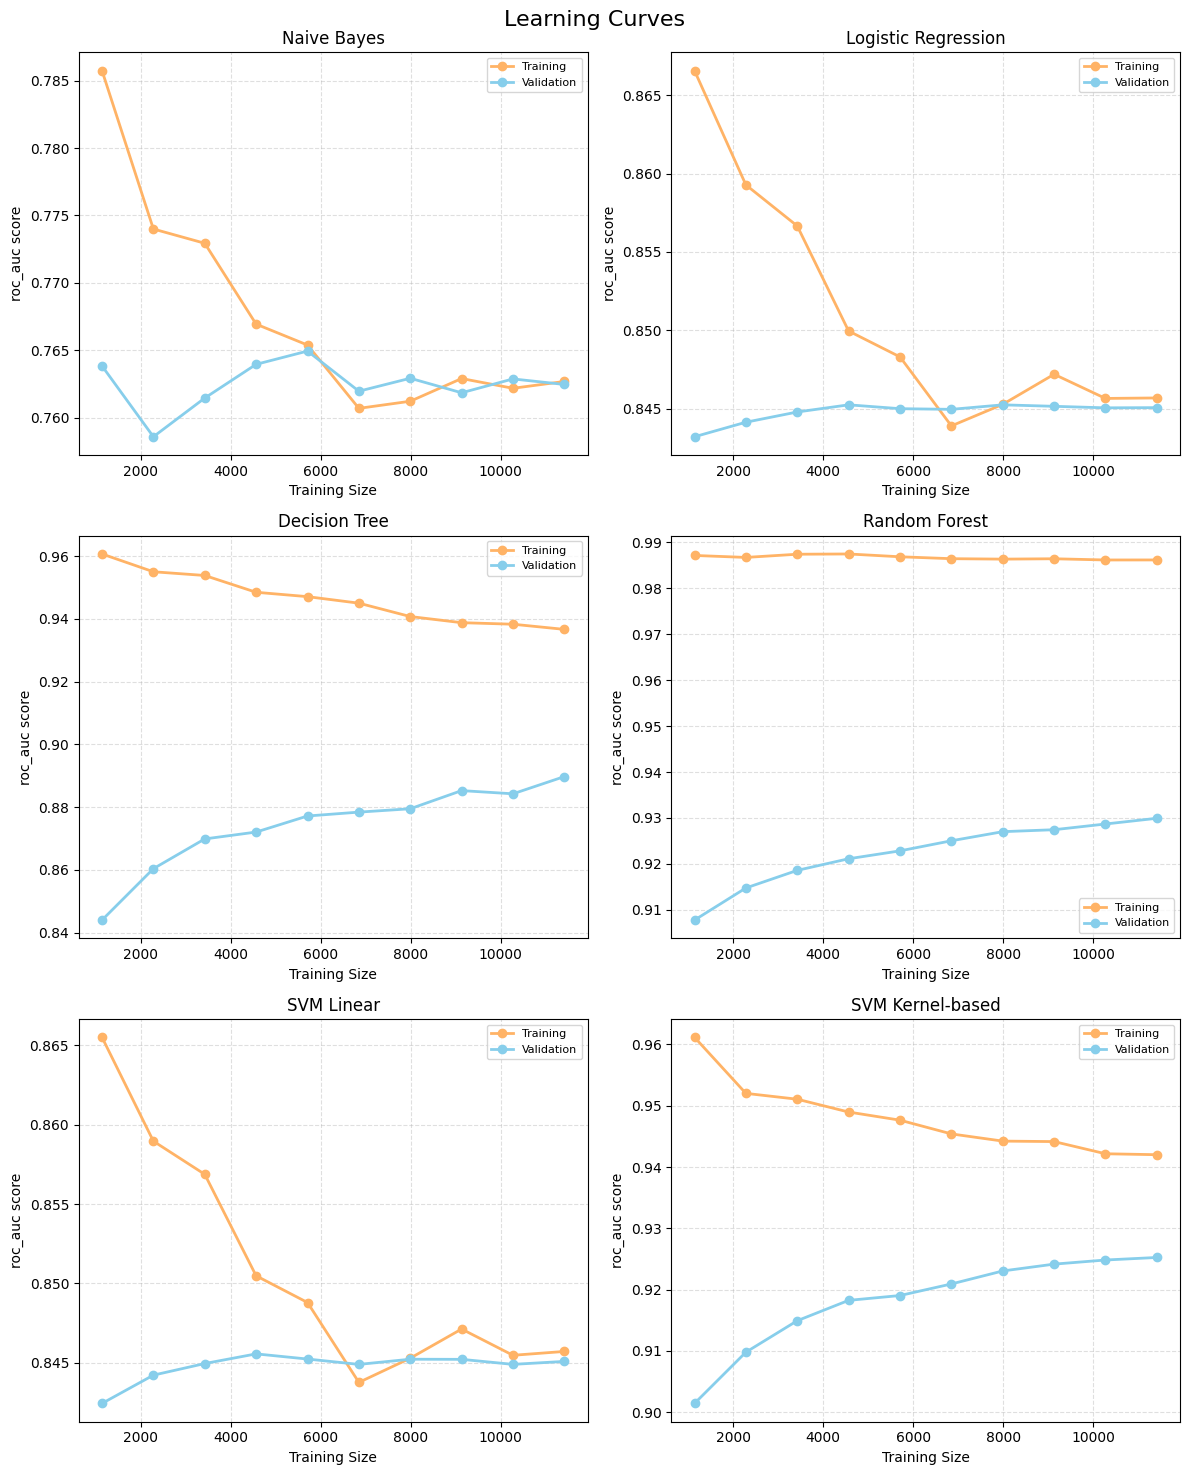

In [51]:
learning_curves(model_results, X_train, y_train)

### **Feature Importances**

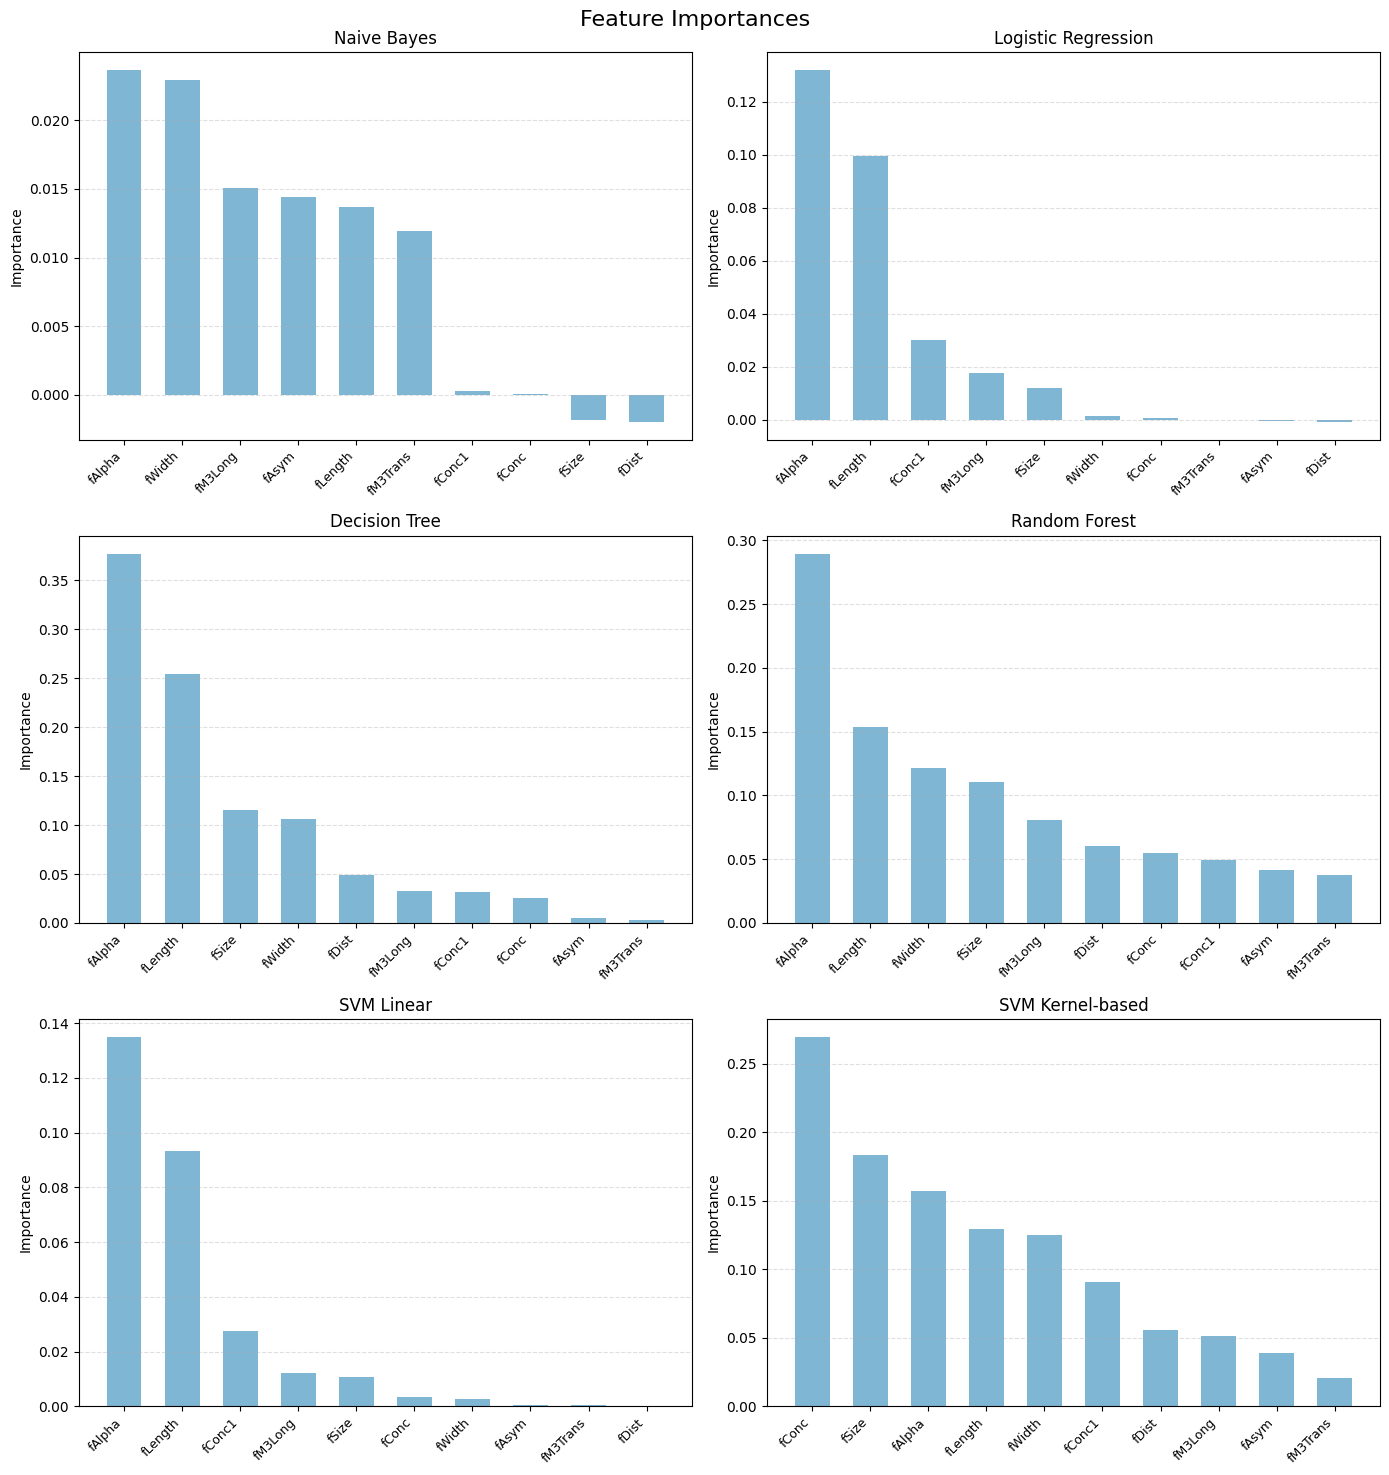

In [52]:
feature_importances(model_results, X_test, y_test, feature_names)

### **Decision Boundaries**

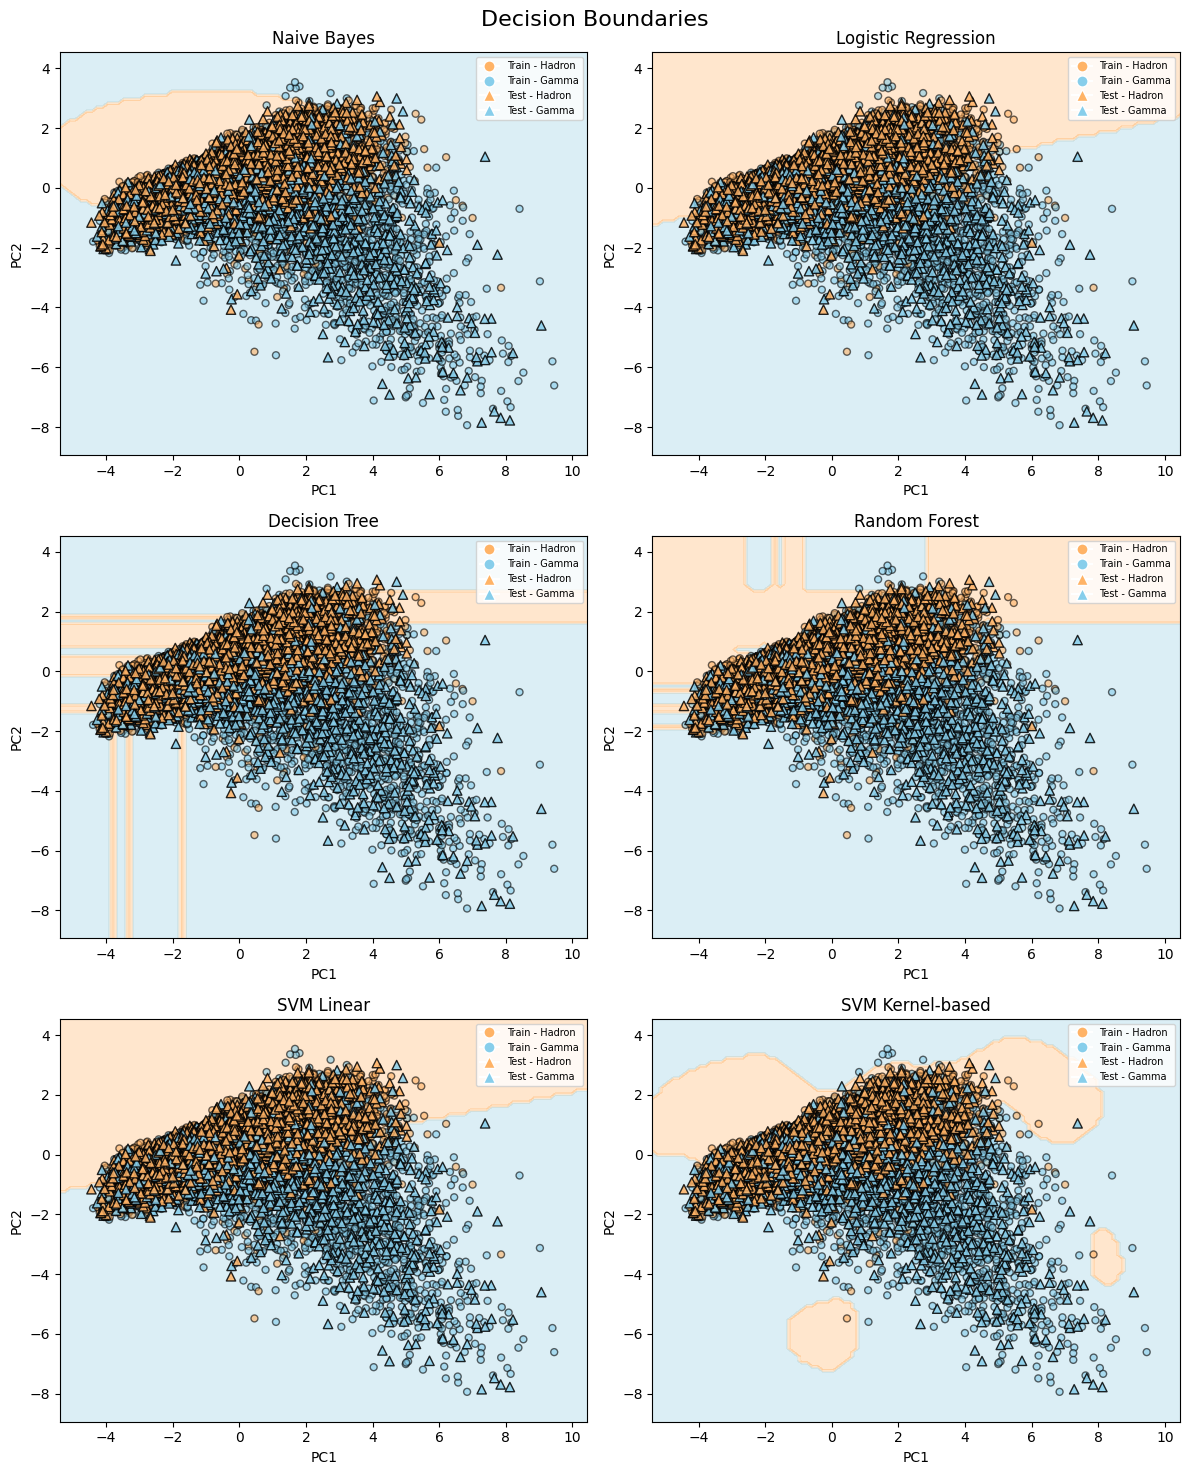

In [53]:
decision_boundaries(model_results, X_train, y_train, X_test, y_test)

### **Training vs Validation**

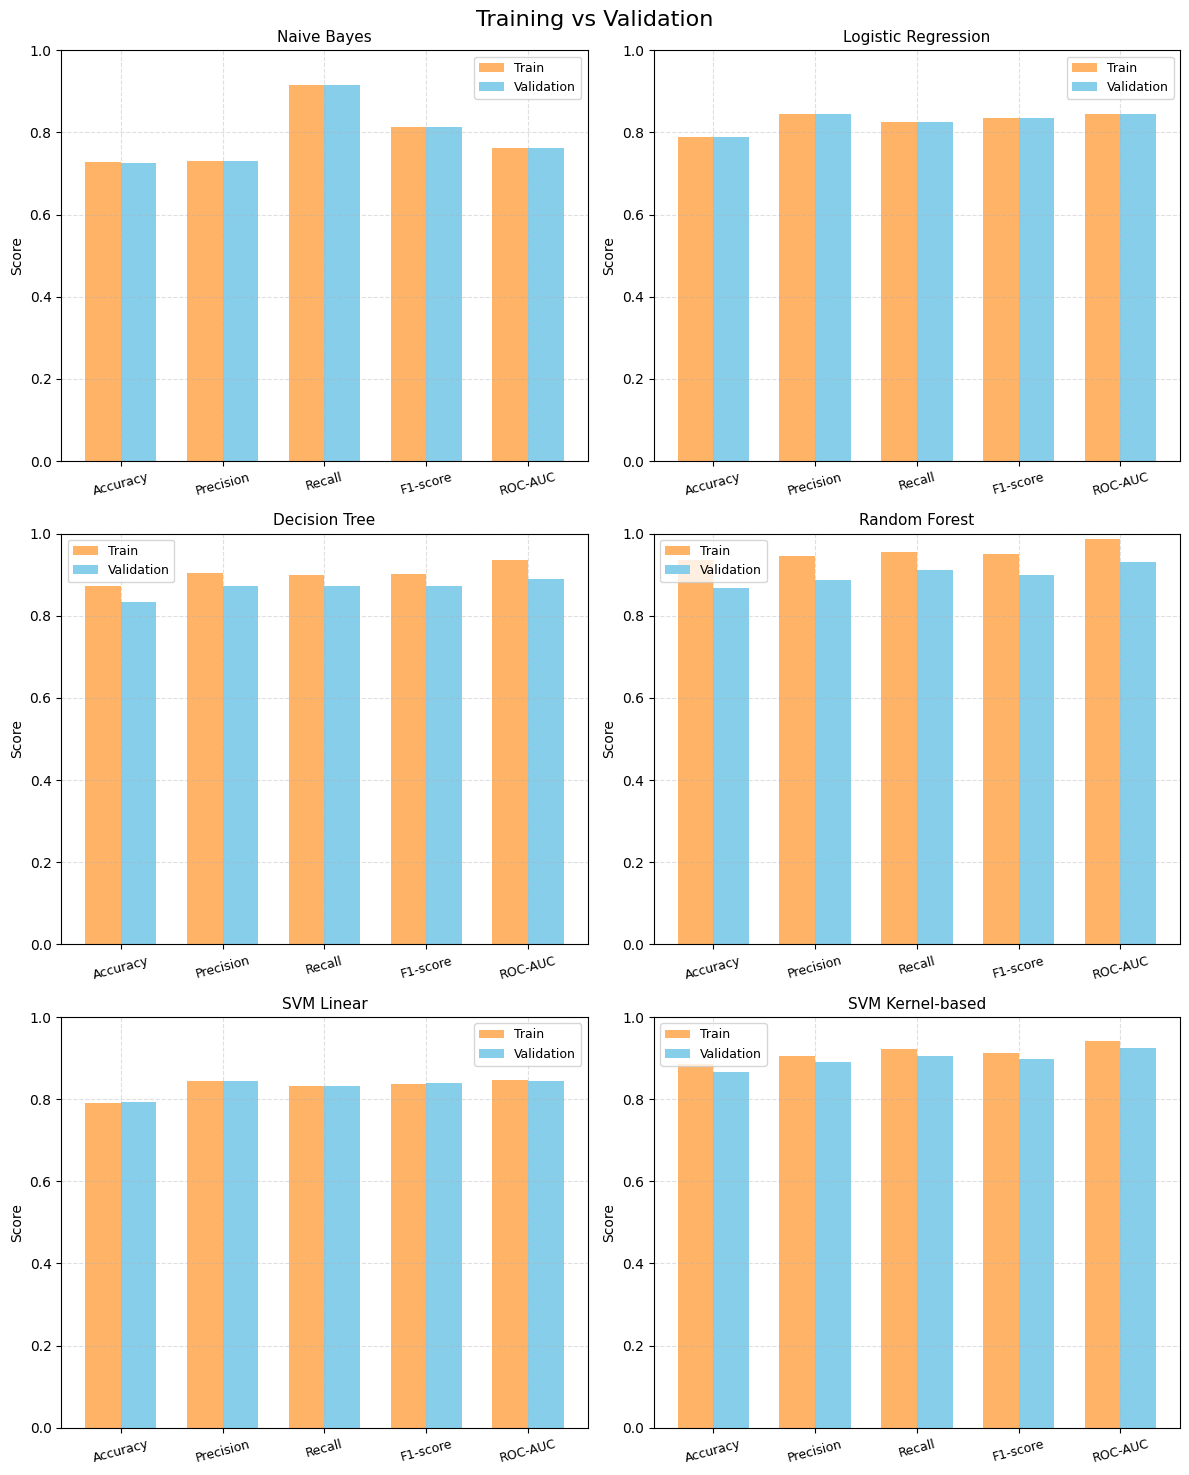

In [54]:
training_vs_validation(model_results, X_train, y_train, performances)

### **Validation Metrics Across Models**

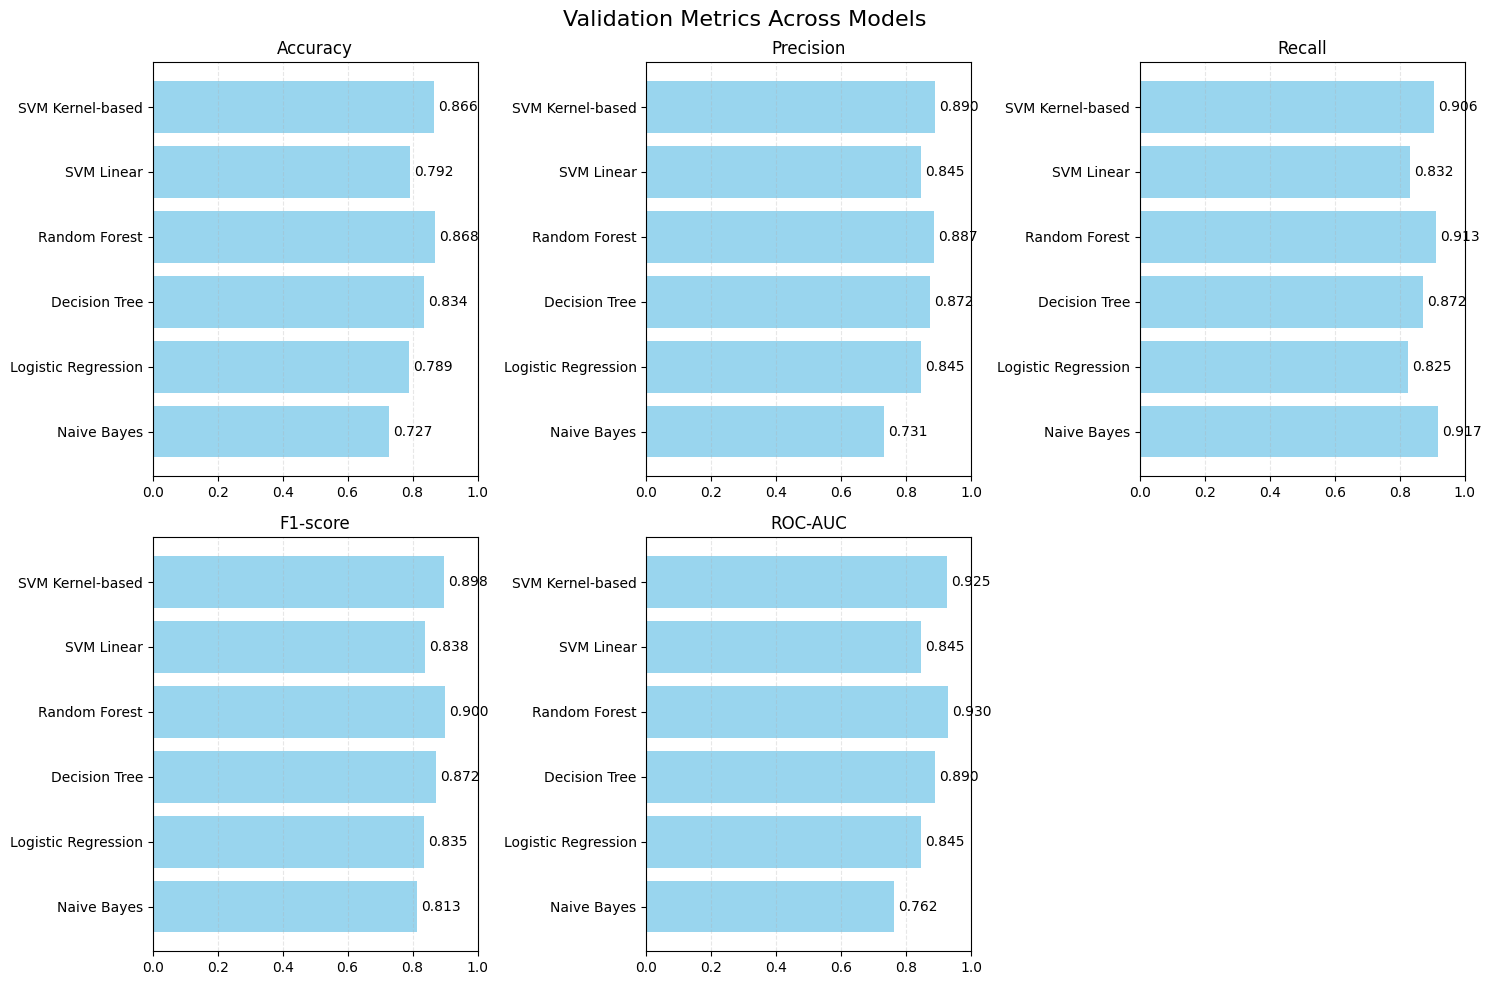

In [55]:
validation_metrics(performances)

### **Training Time Comparison**

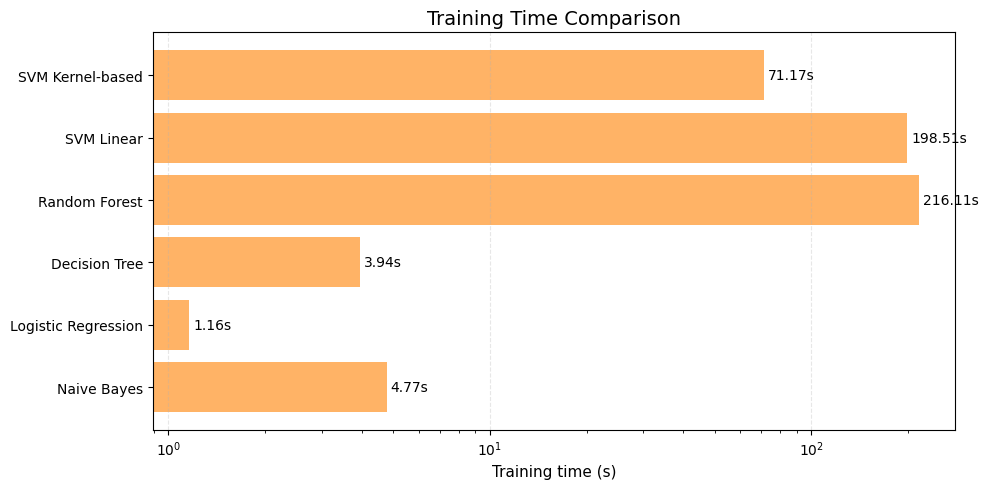

In [56]:
training_times_comparison(training_times_list)